In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import dagshub
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.under_sampling import TomekLinks

from dotenv import load_dotenv
load_dotenv('../.env', override=True)

import os
DAGSHUB_USERNAME  = os.environ['DAGSHUB_USERNAME']
DAGSHUB_REPO_NAME = os.environ['DAGSHUB_REPO_NAME']
DAGSHUB_TOKEN     = os.environ['DAGSHUB_TOKEN']
MLFLOW_EXPERIMENT = os.getenv('MLFLOW_EXPERIMENT', 'wine-predict')
REGISTERED_MODEL  = os.getenv('MLFLOW_MODEL_NAME',  'wine-predict')

print("✅ Imports OK")


/home/fbotero/Documents/Estudos/POS/infra/wine_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


## Carregando Dataset

In [2]:
df = pd.read_csv("../data/wine_quality.csv")
# df = pd.read_csv("../data/wine_quality.csv")
print('Classes :', sorted(df['quality'].unique()))
print(df['quality'].value_counts().sort_index().to_string())   


Classes : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5


## 1. EDA

In [3]:

# ── Visão geral do dataset ───────────────────────────────────
print(f"Shape: {df.shape}")
print(f"\nTipos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstatísticas descritivas:")
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean","std","min","max"])


Shape: (6497, 13)

Tipos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.000000,7.215307,1.296434,3.800000,6.400000,7.000000,7.700000,15.900000
volatile acidity,6497.000000,0.339666,0.164636,0.080000,0.230000,0.290000,0.400000,1.580000
citric acid,6497.000000,0.318633,0.145318,0.000000,0.250000,0.310000,0.390000,1.660000
residual sugar,6497.000000,5.443235,4.757804,0.600000,1.800000,3.000000,8.100000,65.800000
chlorides,6497.000000,0.056034,0.035034,0.009000,0.038000,0.047000,0.065000,0.611000
free sulfur dioxide,6497.000000,30.525319,17.749400,1.000000,17.000000,29.000000,41.000000,289.000000
total sulfur dioxide,6497.000000,115.744574,56.521855,6.000000,77.000000,118.000000,156.000000,440.000000
density,6497.000000,0.994697,0.002999,0.987110,0.992340,0.994890,0.996990,1.038980
pH,6497.000000,3.218501,0.160787,2.720000,3.110000,3.210000,3.320000,4.010000
sulphates,6497.000000,0.531268,0.148806,0.220000,0.430000,0.510000,0.600000,2.000000


### 1.1 Distribuição da variável alvo (`quality`)

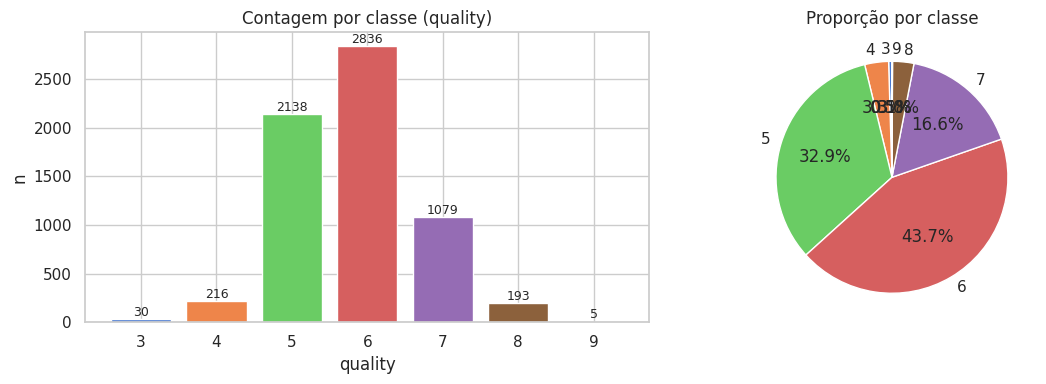

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem absoluta
vc = df["quality"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=sns.color_palette("muted", len(vc)))
axes[0].set_title("Contagem por classe (quality)")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("n")
for bar, v in zip(axes[0].patches, vc.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(v), ha="center", va="bottom", fontsize=9)

# Proporção
axes[1].pie(vc.values, labels=vc.index.astype(str), autopct="%1.1f%%",
            colors=sns.color_palette("muted", len(vc)), startangle=90)
axes[1].set_title("Proporção por classe")

plt.tight_layout()
plt.show()
print(vc.to_string())


### 1.2 Histogramas das features

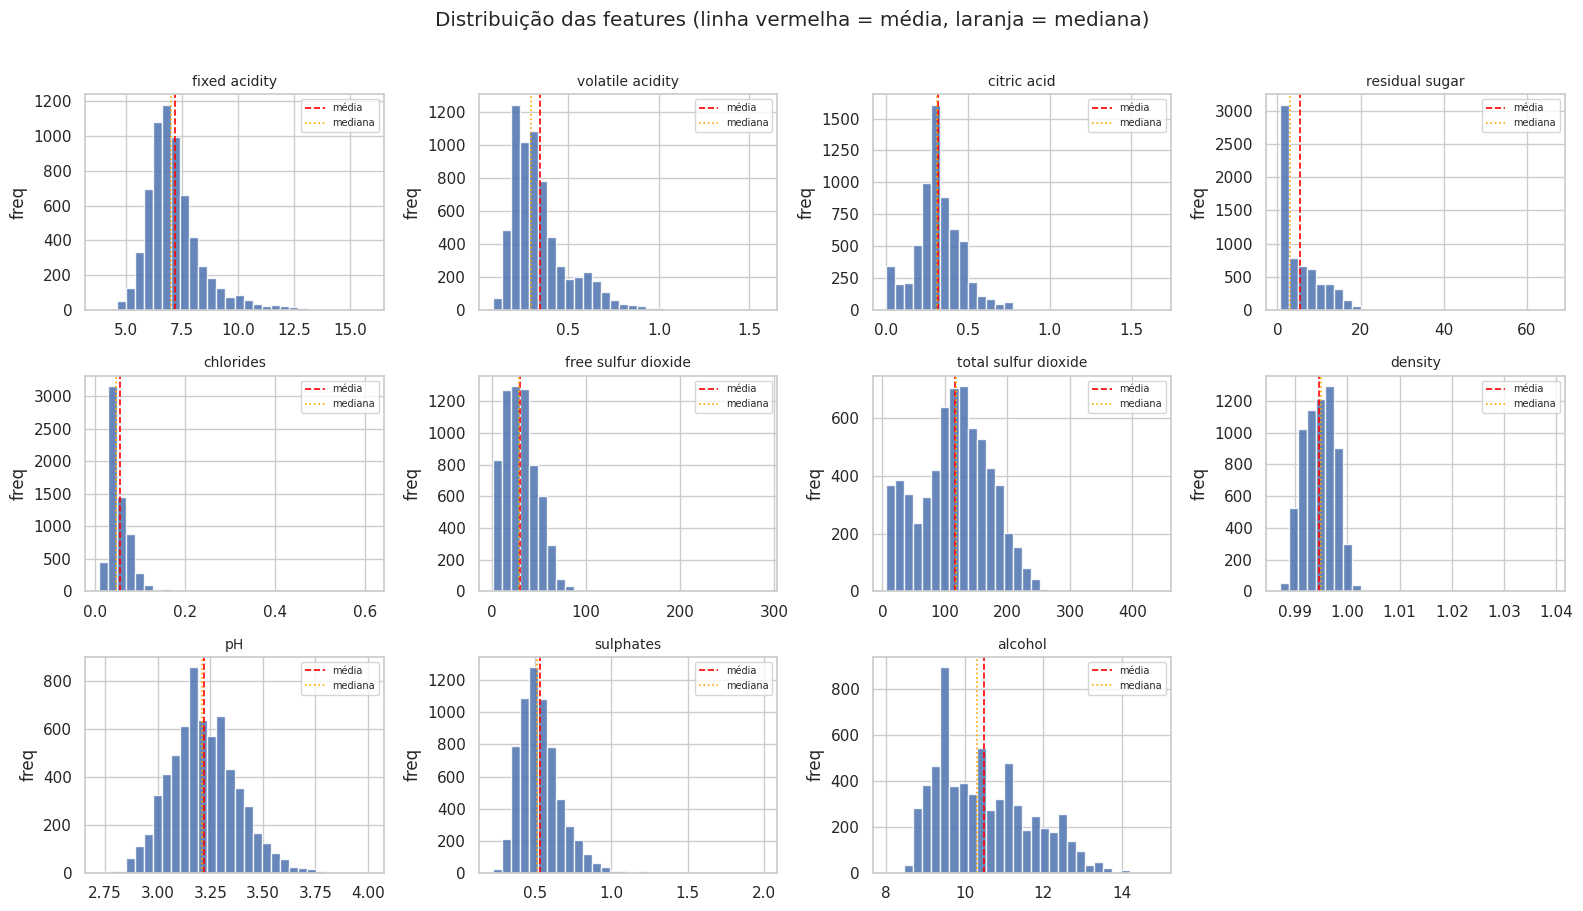

In [5]:
feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "quality"]
n = len(feat_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("freq")
    # linha de média e mediana
    axes[i].axvline(df[col].mean(),   color="red",    linestyle="--", linewidth=1.2, label="média")
    axes[i].axvline(df[col].median(), color="orange", linestyle=":",  linewidth=1.2, label="mediana")
    axes[i].legend(fontsize=7)

# esconder eixos extras
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição das features (linha vermelha = média, laranja = mediana)", y=1.01)
plt.tight_layout()
plt.show()


### 1.3 Boxplots por classe de qualidade

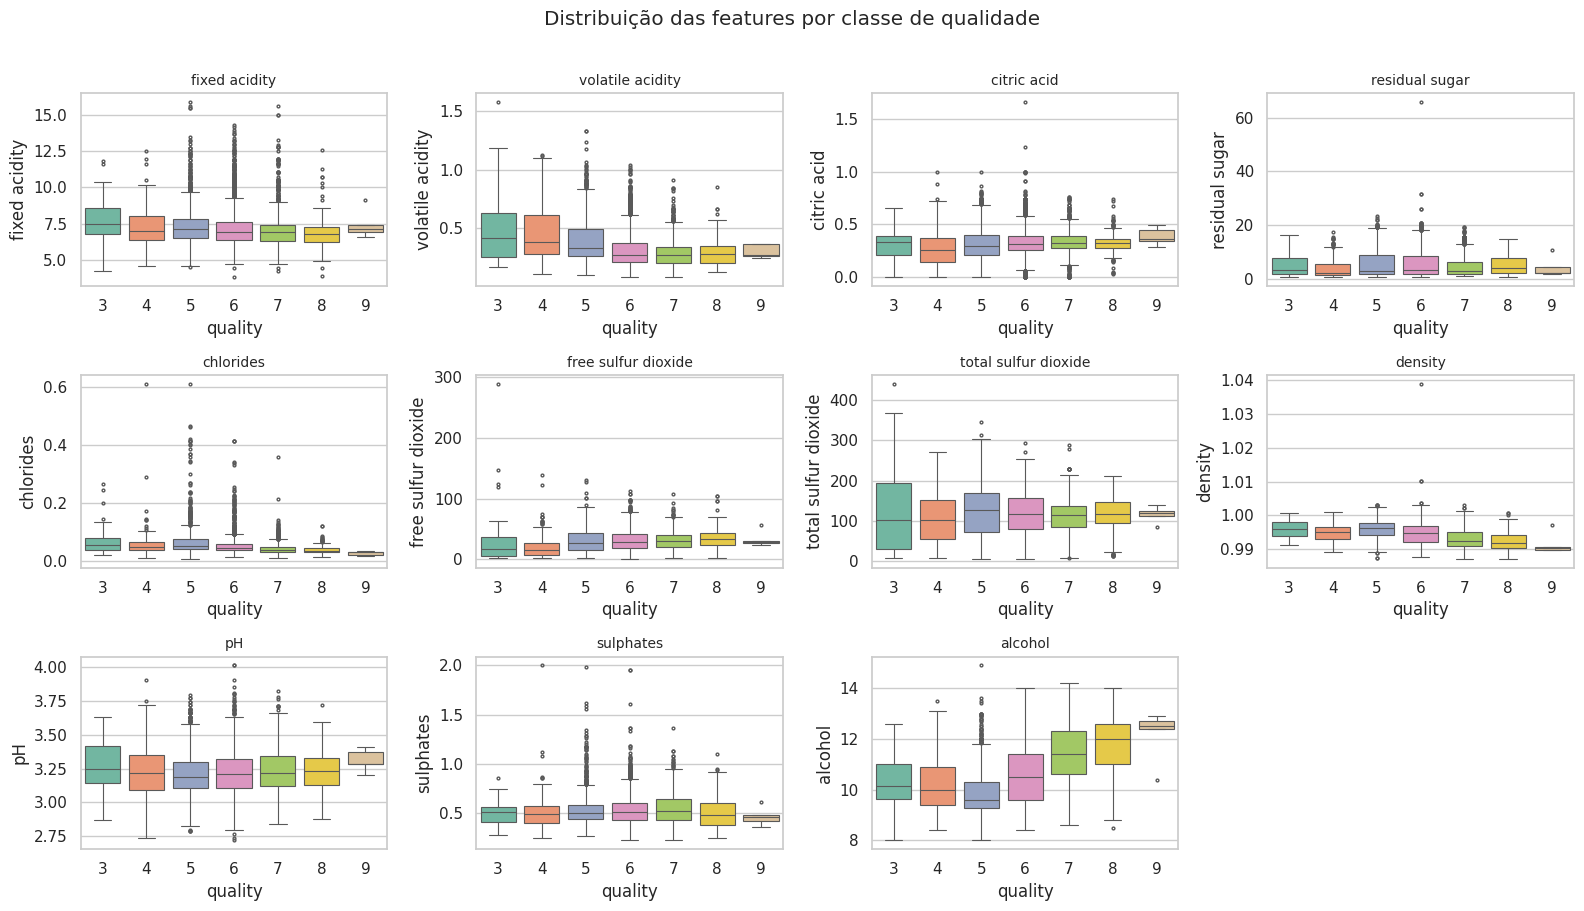

In [6]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    sns.boxplot(data=df, x="quality", y=col, ax=axes[i],
                palette="Set2", linewidth=0.8, fliersize=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("quality")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição das features por classe de qualidade", y=1.01)
plt.tight_layout()
plt.show()


### 1.4 Matriz de correlação

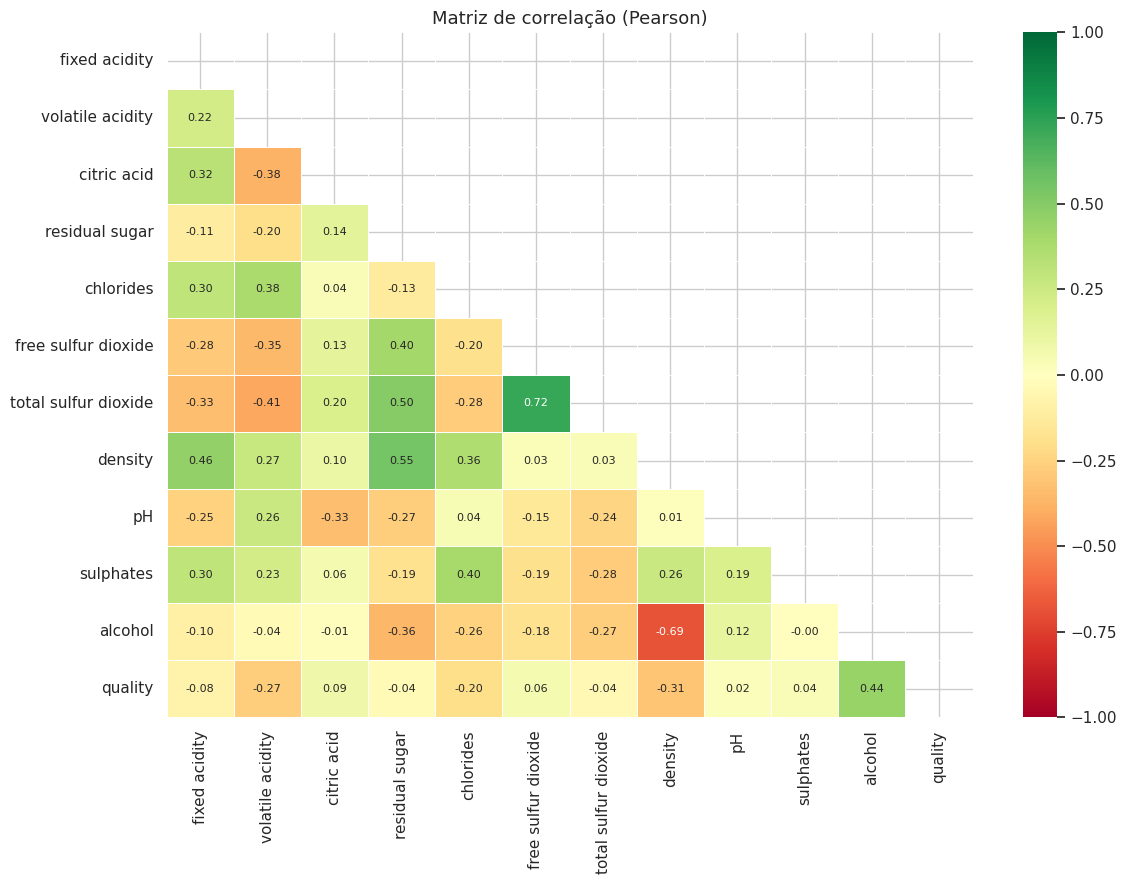


Correlação com 'quality' (ordenada):
alcohol                 0.444319
density                -0.305858
volatile acidity       -0.265699
chlorides              -0.200666
citric acid             0.085532
fixed acidity          -0.076743
free sulfur dioxide     0.055463
total sulfur dioxide   -0.041385
sulphates               0.038485
residual sugar         -0.036980
pH                      0.019506


In [7]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # mostrar só metade inferior
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 8},
    vmin=-1, vmax=1,
)
ax.set_title("Matriz de correlação (Pearson)", fontsize=13)
plt.tight_layout()
plt.show()

# Destacar features mais correlacionadas com quality
print("\nCorrelação com 'quality' (ordenada):")
print(corr["quality"].drop("quality").sort_values(key=abs, ascending=False).to_string())


### 1.5 Detecção de outliers (IQR)

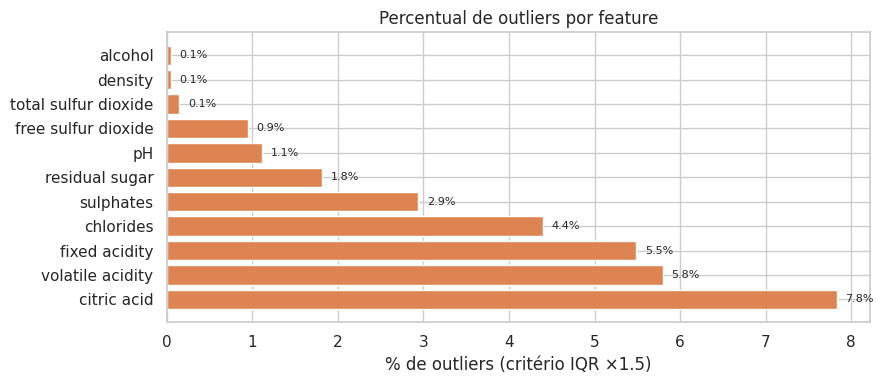

                      n_outliers   pct
citric acid                  509  7.83
volatile acidity             377  5.80
fixed acidity                357  5.49
chlorides                    286  4.40
sulphates                    191  2.94
residual sugar               118  1.82
pH                            73  1.12
free sulfur dioxide           62  0.95
total sulfur dioxide          10  0.15
density                        3  0.05
alcohol                        3  0.05


In [8]:
Q1  = df[feat_cols].quantile(0.25)
Q3  = df[feat_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[feat_cols] < (Q1 - 1.5 * IQR)) | (df[feat_cols] > (Q3 + 1.5 * IQR))).sum()

outlier_df = (
    pd.DataFrame({"n_outliers": outliers, "pct": (outliers / len(df) * 100).round(2)})
    .sort_values("pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(outlier_df.index, outlier_df["pct"], color="#DD8452")
ax.set_xlabel("% de outliers (critério IQR ×1.5)")
ax.set_title("Percentual de outliers por feature")
for bar, pct in zip(ax.patches, outlier_df["pct"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print(outlier_df.to_string())


## 2. Fusão de Classes
| Label | Classe original | Descrição |
|-------|-----------------|-----------|
| **0** | 3, 4, 5, 6 | Ruim |
| **2** | 7, 8, 9 | Bom |


In [9]:
df_merged = df.copy()
df_merged["quality"] = df["quality"].apply(lambda x: "0" if x < 7 else 1)
df_merged['quality'].replace("0",0, inplace=True)
df_merged['quality'].replace("1",1, inplace=True)

# separar X e y
X = df_merged.drop(columns=['quality'])
y_orig = df_merged['quality']
print('Classes após fusão:', sorted(df_merged['quality'].unique()))
print(df_merged['quality'].value_counts().sort_index().to_string())



Classes após fusão: [np.int64(0), np.int64(1)]
quality
0    5220
1    1277


## 3. Split Treino / Validação / Teste  (60 / 20 / 20)

In [10]:
# 1ª divisão: 80% temp + 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_orig, test_size=0.20, random_state=42, stratify=y_orig
)
# 2ª divisão: 75% treino + 25% validação  →  60% / 20% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

total = len(X)
print(f"Treino:    {len(X_train):>5} amostras  ({len(X_train)/total*100:.1f}%)")
print(f"Validação: {len(X_val):>5} amostras  ({len(X_val)/total*100:.1f}%)")
print(f"Teste:     {len(X_test):>5} amostras  ({len(X_test)/total*100:.1f}%)")
print("\nDistribuição no treino:")
print(y_train.value_counts().sort_index())


Treino:     3897 amostras  (60.0%)
Validação:  1300 amostras  (20.0%)
Teste:      1300 amostras  (20.0%)

Distribuição no treino:
quality
0    3131
1     766
Name: count, dtype: int64


### Models

In [11]:
# ── Identificar colunas ──────────────────────────────────────
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
cat_idx  = [X.columns.get_loc(c) for c in cat_cols]

print(f"Numéricas  ({len(num_cols)}): {num_cols}")
print(f"Categóricas({len(cat_cols)}): {cat_cols}")

# ── Fábrica de pré-processador ───────────────────────────────
def make_preprocessor():
    steps = [("num", StandardScaler(), num_cols)]
    if cat_cols:
        steps.append(("cat",
                       OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                       cat_cols))
    return ColumnTransformer(steps)

# ── Fábrica de modelos (instâncias frescas) ───────────────────
def get_models():
    return {
        "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
        "random_forest":       RandomForestClassifier(n_estimators=100, random_state=42),
        "knn":                 KNeighborsClassifier(),
        "svm":                 SVC(random_state=42),
        "xgboost":             XGBClassifier(eval_metric="mlogloss", random_state=42),
        "mlp":                 MLPClassifier(hidden_layer_sizes=(200, 100),
                                             max_iter=2000, random_state=42),
    }

# ── Cálculo de métricas ───────────────────────────────────────
def compute_metrics(y_true, y_pred, prefix=""):
    return {
        f"{prefix}accuracy":  round(accuracy_score(y_true, y_pred), 4),
        f"{prefix}precision": round(precision_score(y_true, y_pred,
                                                    average="weighted",
                                                    zero_division=0), 4),
        f"{prefix}recall":    round(recall_score(y_true, y_pred,
                                                 average="weighted",
                                                 zero_division=0), 4),
        f"{prefix}f1":        round(f1_score(y_true, y_pred,
                                             average="weighted",
                                             zero_division=0), 4),
    }

print("✅ Utilitários definidos")


Numéricas  (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Categóricas(1): ['type']
✅ Utilitários definidos


## 5. Configuração DagHub / MLflow

In [12]:
dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO_NAME, mlflow=True)
mlflow.set_experiment("wine_quality_classification")

print("✅ MLflow tracking URI:", mlflow.get_tracking_uri())


Accessing as frpbotero

Initialized MLflow to track repo "frpbotero/wine-predict"

Repository frpbotero/wine-predict initialized!

✅ MLflow tracking URI: https://dagshub.com/frpbotero/wine-predict.mlflow


---
## Estratégia 1 — SMOTE (Over-sampling)
Aplica **SMOTENC** (suporte a features categóricas) no conjunto de treino para  
balancear as classes.  
Cada modelo é embrulhado num `Pipeline` com pré-processador próprio.


### 6. Aplicar SMOTE ao conjunto de treino

In [13]:
if cat_idx:
    sampler = SMOTENC(categorical_features=cat_idx, random_state=42)
    print("Usando SMOTENC (há features categóricas)")
else:
    sampler = SMOTE(random_state=42)
    print("Usando SMOTE (apenas features numéricas)")

X_train_smote, y_train_smote = sampler.fit_resample(X_train, y_train)

# Manter como DataFrame para compatibilidade com o Pipeline
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = np.array(y_train_smote, dtype=int)

print("\nDistribuição após SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nTotal de amostras: {len(X_train_smote)}")


Usando SMOTENC (há features categóricas)

Distribuição após SMOTE:
0    3131
1    3131
Name: count, dtype: int64

Total de amostras: 6262


### 7. Treinar, validar, testar e registrar — SMOTE

In [15]:
STRATEGY = "SMOTE"
results_smote = {}

for model_name, model in get_models().items():
    print(f"\n{'='*60}")
    print(f"  Estratégia: {STRATEGY}  |  Modelo: {model_name}")
    print(f"{'='*60}")

    # ── Pipeline: pré-processador + classificador ─────────────
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier",   model),
    ])

    # ── Treino ────────────────────────────────────────────────
    pipeline.fit(X_train_smote, y_train_smote)

    # ── Validação ─────────────────────────────────────────────
    y_val_pred  = pipeline.predict(X_val)
    val_metrics = compute_metrics(y_val, y_val_pred, prefix="val_")

    # ── Teste ─────────────────────────────────────────────────
    y_test_pred  = pipeline.predict(X_test)
    test_metrics = compute_metrics(y_test, y_test_pred, prefix="test_")

    all_metrics = {**val_metrics, **test_metrics}
    results_smote[model_name] = all_metrics

    # ── Imprimir resultados ───────────────────────────────────
    print(f"  Validação → Acc:{val_metrics['val_accuracy']:.4f}  "
          f"P:{val_metrics['val_precision']:.4f}  "
          f"R:{val_metrics['val_recall']:.4f}  "
          f"F1:{val_metrics['val_f1']:.4f}")
    print(f"  Teste     → Acc:{test_metrics['test_accuracy']:.4f}  "
          f"P:{test_metrics['test_precision']:.4f}  "
          f"R:{test_metrics['test_recall']:.4f}  "
          f"F1:{test_metrics['test_f1']:.4f}")
    print("\n" + classification_report(y_test, y_test_pred,
                                        target_names=["Ruim(0)", "Bom(1)"]))

    # ── Log no DagHub / MLflow ────────────────────────────────
    with mlflow.start_run(run_name=f"{STRATEGY}_{model_name}"):
        mlflow.log_param("strategy",      STRATEGY)
        mlflow.log_param("model",         model_name)
        mlflow.log_param("train_samples", int(len(X_train_smote)))
        mlflow.log_param("val_samples",   int(len(X_val)))
        mlflow.log_param("test_samples",  int(len(X_test)))
        mlflow.log_metrics(all_metrics)
        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model",
            registered_model_name=f"wine_{STRATEGY}_{model_name}",
        )
    print(f"  ✅ Registrado → wine_{STRATEGY}_{model_name}")

print("\n🎉 SMOTE — todos os modelos registrados no DagHub!")



  Estratégia: SMOTE  |  Modelo: logistic_regression
  Validação → Acc:0.7123  P:0.8199  R:0.7123  F1:0.7404
  Teste     → Acc:0.7115  P:0.8128  R:0.7115  F1:0.7390

              precision    recall  f1-score   support

     Ruim(0)       0.92      0.70      0.80      1044
      Bom(2)       0.38      0.75      0.50       256

    accuracy                           0.71      1300
   macro avg       0.65      0.72      0.65      1300
weighted avg       0.81      0.71      0.74      1300



2026/05/07 20:45:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:46:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_logistic_regression' already exists. Creating a new version of this model...
2026/05/07 20:46:13 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_logistic_regression, version 3
Created version '3' of model 'wine_SMOTE_logistic_regression'.


🏃 View run SMOTE_logistic_regression at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/55bb61a46e194de0b79363ccc3e0fc7e
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_logistic_regression

  Estratégia: SMOTE  |  Modelo: random_forest
  Validação → Acc:0.8415  P:0.8552  R:0.8415  F1:0.8468
  Teste     → Acc:0.8531  P:0.8551  R:0.8531  F1:0.8540

              precision    recall  f1-score   support

     Ruim(0)       0.91      0.90      0.91      1044
      Bom(2)       0.62      0.64      0.63       256

    accuracy                           0.85      1300
   macro avg       0.77      0.77      0.77      1300
weighted avg       0.86      0.85      0.85      1300



2026/05/07 20:46:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:46:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_random_forest' already exists. Creating a new version of this model...
2026/05/07 20:46:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_random_forest, version 3
Created version '3' of model 'wine_SMOTE_random_forest'.


🏃 View run SMOTE_random_forest at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/b3104bc32cad41d3bc5fd521cf672aca
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_random_forest

  Estratégia: SMOTE  |  Modelo: knn
  Validação → Acc:0.7531  P:0.8332  R:0.7531  F1:0.7751
  Teste     → Acc:0.7554  P:0.8251  R:0.7554  F1:0.7759

              precision    recall  f1-score   support

     Ruim(0)       0.92      0.76      0.83      1044
      Bom(2)       0.43      0.74      0.54       256

    accuracy                           0.76      1300
   macro avg       0.68      0.75      0.69      1300
weighted avg       0.83      0.76      0.78      1300



...

🏃 View run SMOTE_svm at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/0a9ee3cf8f60465e9a45dc380552ef15
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_svm

  Estratégia: SMOTE  |  Modelo: xgboost
  Validação → Acc:0.8531  P:0.8542  R:0.8531  F1:0.8536
  Teste     → Acc:0.8569  P:0.8557  R:0.8569  F1:0.8563

              precision    recall  f1-score   support

     Ruim(0)       0.91      0.91      0.91      1044
      Bom(2)       0.64      0.62      0.63       256

    accuracy                           0.86      1300
   macro avg       0.77      0.77      0.77      1300
weighted avg       0.86      0.86      0.86      1300



2026/05/07 20:48:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:48:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_xgboost' already exists. Creating a new version of this model...
2026/05/07 20:48:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_xgboost, version 2
Created version '2' of model 'wine_SMOTE_xgboost'.


🏃 View run SMOTE_xgboost at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/89b930c0892d413abecadc0d8cc21849
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_xgboost

  Estratégia: SMOTE  |  Modelo: mlp
  Validação → Acc:0.8400  P:0.8434  R:0.8400  F1:0.8416
  Teste     → Acc:0.8492  P:0.8484  R:0.8492  F1:0.8488

              precision    recall  f1-score   support

     Ruim(0)       0.90      0.91      0.91      1044
      Bom(2)       0.62      0.61      0.61       256

    accuracy                           0.85      1300
   macro avg       0.76      0.76      0.76      1300
weighted avg       0.85      0.85      0.85      1300



2026/05/07 20:49:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:49:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_mlp' already exists. Creating a new version of this model...
2026/05/07 20:49:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_mlp, version 2
Created version '2' of model 'wine_SMOTE_mlp'.


🏃 View run SMOTE_mlp at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/6f4d8609123c47f29fc6f728a470e893
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_mlp

🎉 SMOTE — todos os modelos registrados no DagHub!


---
## Estratégia 2 — Tomek Links (Under-sampling)
**TomekLinks** requer features numéricas, portanto o pré-processamento  
é aplicado primeiro e compartilhado entre todos os modelos.


### 8. Pré-processar e aplicar Tomek Links

In [16]:
# ── Pré-processamento ────────────────────────────────────────
preprocessor_tomek = make_preprocessor()
X_train_trans = preprocessor_tomek.fit_transform(X_train)
X_val_trans   = preprocessor_tomek.transform(X_val)
X_test_trans  = preprocessor_tomek.transform(X_test)

y_train_int = y_train.values.astype(int)
y_val_int   = y_val.values.astype(int)
y_test_int  = y_test.values.astype(int)

# ── Tomek Links ───────────────────────────────────────────────
tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train_trans, y_train_int)

print("Distribuição após Tomek Links:")
print(pd.Series(y_train_tomek).value_counts().sort_index())
print(f"\nAmostras removidas: {len(X_train_trans) - len(X_train_tomek)}")


Distribuição após Tomek Links:
0    3011
1     766
Name: count, dtype: int64

Amostras removidas: 120


### 9. Treinar, validar, testar e registrar — Tomek Links

In [17]:
STRATEGY = "Tomek"
results_tomek = {}

for model_name, model in get_models().items():
    print(f"\n{'='*60}")
    print(f"  Estratégia: {STRATEGY}  |  Modelo: {model_name}")
    print(f"{'='*60}")

    # ── Treino direto nos dados já transformados ───────────────
    model.fit(X_train_tomek, y_train_tomek)

    # ── Validação ─────────────────────────────────────────────
    y_val_pred  = model.predict(X_val_trans)
    val_metrics = compute_metrics(y_val_int, y_val_pred, prefix="val_")

    # ── Teste ─────────────────────────────────────────────────
    y_test_pred  = model.predict(X_test_trans)
    test_metrics = compute_metrics(y_test_int, y_test_pred, prefix="test_")

    all_metrics = {**val_metrics, **test_metrics}
    results_tomek[model_name] = all_metrics

    # ── Imprimir resultados ───────────────────────────────────
    print(f"  Validação → Acc:{val_metrics['val_accuracy']:.4f}  "
          f"P:{val_metrics['val_precision']:.4f}  "
          f"R:{val_metrics['val_recall']:.4f}  "
          f"F1:{val_metrics['val_f1']:.4f}")
    print(f"  Teste     → Acc:{test_metrics['test_accuracy']:.4f}  "
          f"P:{test_metrics['test_precision']:.4f}  "
          f"R:{test_metrics['test_recall']:.4f}  "
          f"F1:{test_metrics['test_f1']:.4f}")
    print("\n" + classification_report(y_test_int, y_test_pred,
                                        target_names=["Ruim(0)", "Bom(1)"]))

    # ── Log no DagHub / MLflow ────────────────────────────────
    with mlflow.start_run(run_name=f"{STRATEGY}_{model_name}"):
        mlflow.log_param("strategy",      STRATEGY)
        mlflow.log_param("model",         model_name)
        mlflow.log_param("train_samples", int(len(X_train_tomek)))
        mlflow.log_param("val_samples",   int(len(X_val_trans)))
        mlflow.log_param("test_samples",  int(len(X_test_trans)))
        mlflow.log_metrics(all_metrics)

        # Modelo treinado
        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            registered_model_name=f"wine_{STRATEGY}_{model_name}",
        )
        # Pré-processador compartilhado (necessário para inferência futura)
        mlflow.sklearn.log_model(
            preprocessor_tomek,
            artifact_path="preprocessor",
        )
    print(f"  ✅ Registrado → wine_{STRATEGY}_{model_name}")

print("\n🎉 Tomek — todos os modelos registrados no DagHub!")



  Estratégia: Tomek  |  Modelo: logistic_regression
  Validação → Acc:0.8169  P:0.7905  R:0.8169  F1:0.7932
  Teste     → Acc:0.8200  P:0.7961  R:0.8200  F1:0.7989

              precision    recall  f1-score   support

     Ruim(0)       0.85      0.94      0.89      1044
      Bom(1)       0.58      0.32      0.41       256

    accuracy                           0.82      1300
   macro avg       0.71      0.63      0.65      1300
weighted avg       0.80      0.82      0.80      1300



2026/05/07 20:50:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:50:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_Tomek_logistic_regression' already exists. Creating a new version of this model...
2026/05/07 20:50:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_logistic_regression, version 2
Created version '2' of model 'wine_Tomek_logistic_regression'.
2026/05/07 20:50:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:50:47 WARNING m

🏃 View run Tomek_logistic_regression at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/ff5e62af3ae64a59aa66218369f927c1
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_logistic_regression

  Estratégia: Tomek  |  Modelo: random_forest
  Validação → Acc:0.8846  P:0.8783  R:0.8846  F1:0.8781
  Teste     → Acc:0.8715  P:0.8631  R:0.8715  F1:0.8625

              precision    recall  f1-score   support

     Ruim(0)       0.89      0.96      0.92      1044
      Bom(1)       0.75      0.52      0.62       256

    accuracy                           0.87      1300
   macro avg       0.82      0.74      0.77      1300
weighted avg       0.86      0.87      0.86      1300



2026/05/07 20:51:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:51:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_Tomek_random_forest' already exists. Creating a new version of this model...
2026/05/07 20:51:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_random_forest, version 2
Created version '2' of model 'wine_Tomek_random_forest'.
2026/05/07 20:51:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:51:41 WARNING mlflow.sklearn: Sav

🏃 View run Tomek_random_forest at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/1f43256e494247b8aa57eafd9d9dce29
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_random_forest

  Estratégia: Tomek  |  Modelo: knn
  Validação → Acc:0.8323  P:0.8285  R:0.8323  F1:0.8302
  Teste     → Acc:0.8154  P:0.8132  R:0.8154  F1:0.8143

              precision    recall  f1-score   support

     Ruim(0)       0.88      0.89      0.89      1044
      Bom(1)       0.53      0.52      0.52       256

    accuracy                           0.82      1300
   macro avg       0.71      0.70      0.70      1300
weighted avg       0.81      0.82      0.81      1300



...

🏃 View run Tomek_svm at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/8be0bfeaf1404a31ae89d1bed486a676
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_svm

  Estratégia: Tomek  |  Modelo: xgboost
  Validação → Acc:0.8608  P:0.8571  R:0.8608  F1:0.8587
  Teste     → Acc:0.8631  P:0.8556  R:0.8631  F1:0.8578

              precision    recall  f1-score   support

     Ruim(0)       0.90      0.94      0.92      1044
      Bom(1)       0.69      0.56      0.62       256

    accuracy                           0.86      1300
   macro avg       0.79      0.75      0.77      1300
weighted avg       0.86      0.86      0.86      1300



2026/05/07 20:53:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:53:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'wine_Tomek_xgboost'.
2026/05/07 20:54:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_xgboost, version 1
Created version '1' of model 'wine_Tomek_xgboost'.
2026/05/07 20:54:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:54:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format 

🏃 View run Tomek_xgboost at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/9d384a9c01f141d9a2a80b4b765bed92
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_xgboost

  Estratégia: Tomek  |  Modelo: mlp
  Validação → Acc:0.8515  P:0.8531  R:0.8515  F1:0.8523
  Teste     → Acc:0.8408  P:0.8424  R:0.8408  F1:0.8416

              precision    recall  f1-score   support

     Ruim(0)       0.90      0.90      0.90      1044
      Bom(1)       0.59      0.61      0.60       256

    accuracy                           0.84      1300
   macro avg       0.75      0.75      0.75      1300
weighted avg       0.84      0.84      0.84      1300



2026/05/07 20:55:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:55:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'wine_Tomek_mlp'.
2026/05/07 20:55:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_mlp, version 1
Created version '1' of model 'wine_Tomek_mlp'.
2026/05/07 20:55:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:55:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exe

🏃 View run Tomek_mlp at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1/runs/5d2f2d34245c4f9998fcf156c3fefae5
🧪 View experiment at: https://dagshub.com/frpbotero/wine-predict.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_mlp

🎉 Tomek — todos os modelos registrados no DagHub!


---
## 10. Resumo Final

In [18]:
import pandas as pd

rows = []
for model_name in get_models().keys():
    sm = results_smote.get(model_name, {})
    tk = results_tomek.get(model_name, {})
    rows.append({
        "Modelo":          model_name,
        "SMOTE  Val-F1":   sm.get("val_f1",  "-"),
        "SMOTE  Test-F1":  sm.get("test_f1", "-"),
        "SMOTE  Test-Acc": sm.get("test_accuracy", "-"),
        "Tomek  Val-F1":   tk.get("val_f1",  "-"),
        "Tomek  Test-F1":  tk.get("test_f1", "-"),
        "Tomek  Test-Acc": tk.get("test_accuracy", "-"),
    })

summary = pd.DataFrame(rows).set_index("Modelo")
print(summary.to_string())
print("\n🏆 Melhor Test-F1 SMOTE :", summary["SMOTE  Test-F1"].max(),
      "→", summary["SMOTE  Test-F1"].idxmax())
print("🏆 Melhor Test-F1 Tomek :", summary["Tomek  Test-F1"].max(),
      "→", summary["Tomek  Test-F1"].idxmax())


                     SMOTE  Val-F1  SMOTE  Test-F1  SMOTE  Test-Acc  Tomek  Val-F1  Tomek  Test-F1  Tomek  Test-Acc
Modelo                                                                                                             
logistic_regression         0.7404          0.7390           0.7115         0.7932          0.7989           0.8200
random_forest               0.8468          0.8540           0.8531         0.8781          0.8625           0.8715
knn                         0.7751          0.7759           0.7554         0.8302          0.8143           0.8154
svm                         0.7781          0.7837           0.7631         0.8136          0.8061           0.8285
xgboost                     0.8536          0.8563           0.8569         0.8587          0.8578           0.8631
mlp                         0.8416          0.8488           0.8492         0.8523          0.8416           0.8408

🏆 Melhor Test-F1 SMOTE : 0.8563 → xgboost
🏆 Melhor Test-F1 Tomek : 0.86